# Brain Tumour Detection — **PyTorch Equivalent** (Cell-by-Cell Conversion)
This notebook mirrors your original TensorFlow/Keras notebook cell by cell. For each original cell, I explain the PyTorch changes and provide equivalent code.

**Note:** Paths in your original notebook point to `D:/ujjwal/programming/...`. Update them to your local machine before running.


## Original Cell 1 — Imports
**What it did:** Imported NumPy, TensorFlow/Keras, scikit-learn, OpenCV, Matplotlib, etc.

**PyTorch equivalent:** Replace TensorFlow/Keras with PyTorch (`torch`, `torchvision` optional).

In [1]:

import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
# (Optional) set a seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)


## Original Cell 2 — Load images from folders into `X` and `Y`
**What it did:**
- Defined `base_path` for `Testing` then `Training`, reading images from each class folder.
- Resized to 150×150 with OpenCV, appended to Python lists, then converted to NumPy arrays `X` and `Y`.
- Printed shapes.

**PyTorch equivalent:**
- Do the same reading with OpenCV and `numpy`.
- We'll keep H×W×C in NumPy for now (like Keras). Normalization and channel reordering will be handled in a Dataset class later.

In [13]:

# ----- Update these to your actual folders -----
test_base = r"/home/ujjwal-hirwani/Projects/DL_Projects/Brain Tumor Detection/archive/Testing"
train_base = r"/home/ujjwal-hirwani/Projects/DL_Projects/Brain Tumor Detection/archive/Training"
categories = ['glioma', 'meningioma', 'notumor', 'pituitary']
IMG_SIZE = 150

X_list, Y_list = [], []

def load_from_base(base_path, categories, img_size):
    for label, category in enumerate(categories):
        folder_path = os.path.join(base_path, category)
        if not os.path.isdir(folder_path):
            print(f"Warning: {folder_path} not found")
            continue
        for img_name in os.listdir(folder_path):
            img_path = os.path.join(folder_path, img_name)
            try:
                img = cv2.imread(img_path)
                if img is None:
                    print(f"Failed to read (None): {img_path}")
                    continue
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # RGB like Keras plotting
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                X_list.append(img)
                Y_list.append(label)
            except Exception as e:
                print(f"Error reading {img_path}: {e}")

load_from_base(test_base, categories, IMG_SIZE)
load_from_base(train_base, categories, IMG_SIZE)

X = np.array(X_list)
Y = np.array(Y_list)

print("X shape:", X.shape)  # (N, 150, 150, 3)
print("Y shape:", Y.shape)  # (N,)


X shape: (7023, 150, 150, 3)
Y shape: (7023,)


## Original Cell 3 — `Y = Y.reshape(len(Y), 1)`
**What it did:** Reshaped labels to a column vector for Keras' sparse target handling.

**PyTorch equivalent:**
- PyTorch's `CrossEntropyLoss` expects class indices as 1D vector (shape `[N]`).
- **No reshape needed**; ensure `Y` is `int64` (PyTorch's `long`).

In [14]:

# In PyTorch we keep labels as 1D integer array
Y = Y.astype(np.int64)  # class indices
print("Labels dtype (should be int64):", Y.dtype)


Labels dtype (should be int64): int64


## Original Cell 4 — Normalize `X = X / 255.0`
**What it did:** Scaled pixel values to [0,1].

**PyTorch equivalent:**
- We'll normalize inside the Dataset to keep a clean pipeline, but this mirrors the intent.

In [15]:

# We'll normalize in Dataset; keeping this for parity (optional)
X = X.astype(np.float32) / 255.0


## Original Cell 5 — Visualize a random sample
**What it did:** Picked a random index, showed `X[idx]` and `Y[idx]`.

**PyTorch equivalent:** Same visualization using Matplotlib.

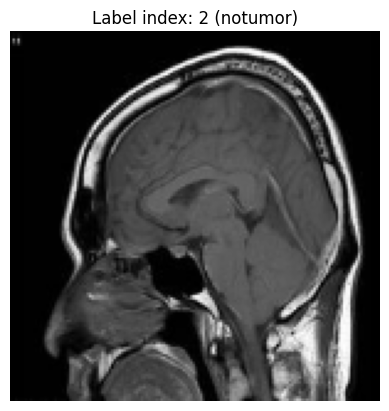

In [16]:

idx = random.randint(0, len(X) - 1)
plt.imshow(X[idx])
plt.title(f"Label index: {Y[idx]} ({categories[Y[idx]]})")
plt.axis('off')
plt.show()


## Original Cell 6 — Label distribution bar chart
**What it did:** Used `np.unique(..., return_counts=True)` to plot class counts.

**PyTorch equivalent:** Identical `numpy` + `matplotlib`.

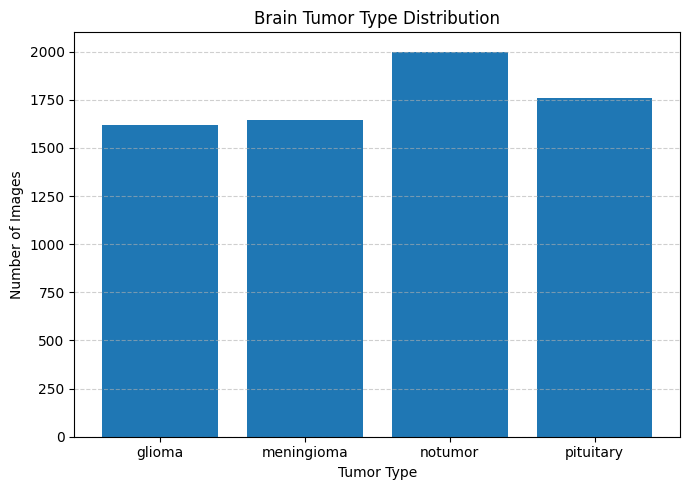

In [17]:
unique, counts = np.unique(Y, return_counts=True)
plt.figure(figsize=(7,5))
plt.bar([categories[u] for u in unique], counts)
plt.xlabel('Tumor Type')
plt.ylabel('Number of Images')
plt.title('Brain Tumor Type Distribution')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## Original Cell 7 — `train_test_split(..., stratify=Y)`
**What it did:** Created train/test splits with class stratification.

**PyTorch equivalent:** Use the same `train_test_split` output to build PyTorch Datasets.

In [18]:

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, stratify=Y, random_state=42
)
print(X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)


(5618, 150, 150, 3) (1405, 150, 150, 3) (5618,) (1405,)


## Original Cell 8 — Shapes, dtypes, memory
**What it did:** Printed shapes/dtypes and memory usage.

**PyTorch equivalent:** Same prints. We'll also show memory for tensors later.

In [19]:

print("X_train shape:", X_train.shape, "dtype:", X_train.dtype)
print("Y_train shape:", Y_train.shape, "dtype:", Y_train.dtype)
print(f"X_train size: {X_train.nbytes / (1024 ** 2):.2f} MB")
print(f"Y_train size: {Y_train.nbytes / (1024 ** 2):.2f} MB")


X_train shape: (5618, 150, 150, 3) dtype: float32
Y_train shape: (5618,) dtype: int64
X_train size: 1446.59 MB
Y_train size: 0.04 MB


## Original Cell 9 — Cast arrays to `float32`
**What it did:** `X_train`/`X_test` cast to `float32`.

**PyTorch equivalent:** We'll cast inside Dataset when converting to tensors.

In [20]:

# (Optional here since Dataset will handle it)
X_train = X_train.astype('float32')
X_test  = X_test.astype('float32')


## Bridge — Create a PyTorch `Dataset` and `DataLoader`
**Why needed in PyTorch:** We feed batches as CHW tensors. We also normalize here.

- Convert images from HWC `[H,W,C]` to CHW `[C,H,W]`.
- Normalize to `[0,1]` (already scaled, but ensure dtype `float32`).

In [21]:

class NumpyImageDataset(Dataset):
    def __init__(self, X_np, y_np):
        self.X = X_np
        self.y = y_np

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx]  # HWC, float32 in [0,1]
        if img.dtype != np.float32:
            img = img.astype(np.float32)
        # HWC -> CHW
        img = np.transpose(img, (2, 0, 1))
        img_t = torch.from_numpy(img)  # float32
        label_t = torch.tensor(self.y[idx], dtype=torch.long)
        return img_t, label_t

batch_size = 32
train_ds = NumpyImageDataset(X_train, Y_train)
test_ds  = NumpyImageDataset(X_test,  Y_test)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=0)


## Original Cell 10 — Keras CNN (Conv→BN→Pool ×3, Flatten, Dense 128→64, Dropout, Softmax)
**What it did:** Defined a 3-block CNN, compiled with Adam(lr=1e-4), sparse cross-entropy.

**PyTorch equivalent:**
- Define an `nn.Module` with the same conv blocks. Use `CrossEntropyLoss` (so **no softmax** in the model—loss applies it internally).
- For 150×150 input, three 2×2 pools reduce spatial size to 18×18. Flatten dim = `128*18*18`.
- Use Adam with `lr=1e-4`.

In [22]:

class BrainTumorCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # same padding
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),  # 150 -> 75

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),  # 75 -> 37

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),  # 37 -> 18
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 18 * 18, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),

            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),

            nn.Linear(64, num_classes)  # logits
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device used: ", device)
model = BrainTumorCNN(num_classes=4).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print(model)


Device used:  cuda
BrainTumorCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=41472, 

## Original Cell 11 — `model.fit(X_train, Y_train, epochs=15, batch_size=32)`
**What it did:** Trained for 15 epochs on train split.

**PyTorch equivalent:** Standard training loop over `train_loader`. Tracks loss and accuracy.

In [23]:

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)             # logits
        loss = criterion(outputs, labels) # CE
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total if total > 0 else 0.0
    epoch_acc = correct / total if total > 0 else 0.0
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    epoch_loss = running_loss / total if total > 0 else 0.0
    epoch_acc = correct / total if total > 0 else 0.0
    return epoch_loss, epoch_acc

epochs = 15
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc     = evaluate(model, test_loader, criterion, device)
    print(f"Epoch {epoch:02d}/{epochs} | "
          f"train_loss={train_loss:.4f} acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} acc={val_acc:.4f}")


Epoch 01/15 | train_loss=0.7092 acc=0.7245 | val_loss=0.3399 acc=0.8733
Epoch 02/15 | train_loss=0.4048 acc=0.8521 | val_loss=0.2400 acc=0.9068
Epoch 03/15 | train_loss=0.2860 acc=0.8991 | val_loss=0.1980 acc=0.9231
Epoch 04/15 | train_loss=0.2128 acc=0.9254 | val_loss=0.1687 acc=0.9359
Epoch 05/15 | train_loss=0.1555 acc=0.9454 | val_loss=0.1683 acc=0.9367
Epoch 06/15 | train_loss=0.1176 acc=0.9619 | val_loss=0.1285 acc=0.9552
Epoch 07/15 | train_loss=0.0818 acc=0.9731 | val_loss=0.1424 acc=0.9495
Epoch 08/15 | train_loss=0.0525 acc=0.9831 | val_loss=0.1380 acc=0.9601
Epoch 09/15 | train_loss=0.0525 acc=0.9836 | val_loss=0.1212 acc=0.9623
Epoch 10/15 | train_loss=0.0385 acc=0.9886 | val_loss=0.1350 acc=0.9594
Epoch 11/15 | train_loss=0.0415 acc=0.9881 | val_loss=0.1228 acc=0.9637
Epoch 12/15 | train_loss=0.0305 acc=0.9897 | val_loss=0.1187 acc=0.9651
Epoch 13/15 | train_loss=0.0251 acc=0.9918 | val_loss=0.1339 acc=0.9658
Epoch 14/15 | train_loss=0.0222 acc=0.9936 | val_loss=0.1354 acc

## Original Cell 12 — `model.evaluate(X_test, Y_test, ...)`
**What it did:** Reported test loss & accuracy.

**PyTorch equivalent:** Use the `evaluate` helper.

In [24]:

test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test Accuracy: {test_acc:.4f}") 
print(f"Test Loss: {test_loss:.4f}")


Test Accuracy: 0.9623
Test Loss: 0.1233


## Original Cell 13 — `X = X.astype('float32')`
**What it did:** Cast whole `X` to `float32` (redundant earlier).

**PyTorch equivalent:** Already handled; images are float32 tensors in `[0,1]`. No extra action required here (kept as a comment).

In [25]:
# Cast already handled in Dataset — no-op in PyTorch
pass

## Original Cell 14 — Re-define model (same architecture)
**What it did:** Created a fresh Keras model again.

**PyTorch equivalent:** If you truly want a fresh model, re-instantiate and re-initialize.

In [26]:

# Fresh model (optional)
fresh_model = BrainTumorCNN(num_classes=4).to(device)
fresh_optimizer = torch.optim.Adam(fresh_model.parameters(), lr=1e-4)
# You could retrain `fresh_model` on a different split if desired.


## Original Cell 15 — `model.fit(X, Y, ...)` (training on ALL data)
**What it did:** Trained on the entire dataset (no holdout). **Not recommended** for honest evaluation.

**PyTorch equivalent:** Provided as an optional example; disabled by default.

In [27]:

TRAIN_ON_FULL = False  # WARNING: Not recommended (no test holdout)
if TRAIN_ON_FULL:
    full_ds = NumpyImageDataset(X, Y)
    full_loader = DataLoader(full_ds, batch_size=32, shuffle=True, num_workers=0)
    model_full = BrainTumorCNN(num_classes=4).to(device)
    opt_full = torch.optim.Adam(model_full.parameters(), lr=1e-4)

    for epoch in range(1, 16):
        tr_loss, tr_acc = train_one_epoch(model_full, full_loader, opt_full, criterion, device)
        print(f"[FULL] Epoch {epoch:02d}/15 | loss={tr_loss:.4f} acc={tr_acc:.4f}")


## Original Cell 16 — `model.save('cnn_model.h5')`
**What it did:** Saved the trained Keras model to an HDF5 file.

**PyTorch equivalent:** Save weights (`state_dict`) or the entire model. Weights-only is the recommended approach.

In [28]:

# Save only weights (recommended)
torch.save(model.state_dict(), "cnn_model_state.pt")

# Or save the entire model (less portable)
torch.save(model, "cnn_model_full.pth")


## Original Cell 17 — Random prediction and visualization
**What it did:** Picked a random image from `X`, predicted with the trained model.

**PyTorch equivalent:** Put the model in `eval()` mode, run a forward pass, argmax the logits.

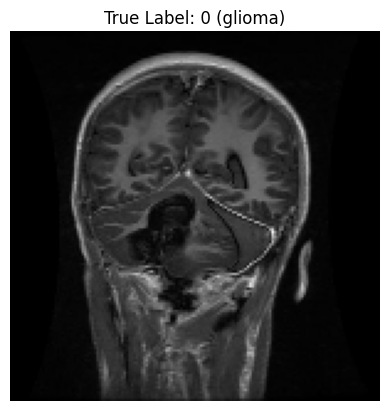

Predicted Label: 0 (glioma)


In [33]:

model.eval()
with torch.no_grad():
    idx = random.randint(0, len(X) - 1)
    image = X[idx]  # HWC, float32 in [0,1]
    true_label = int(Y[idx])

    plt.imshow(image)
    plt.title(f"True Label: {true_label} ({categories[true_label]})")
    plt.axis('off')
    plt.show()

    # Prepare tensor: HWC->[C,H,W]
    img = np.transpose(image, (2, 0, 1))
    img_t = torch.from_numpy(img).unsqueeze(0).to(device)  # [1,3,150,150]

    logits = model(img_t)
    pred_class = int(torch.argmax(logits, dim=1).cpu().item())
    print(f"Predicted Label: {pred_class} ({categories[pred_class]})")
